# NAB Anomaly Detection — LSTM Autoencoder

**Goal:** Train an LSTM Autoencoder on `ec2_cpu_utilization_825cc2.csv`, learning normal 
temporal patterns from anomaly-free segments, then use reconstruction error as an anomaly 
score. This notebook validates the approach on a single file before generalizing and 
comparing against the Isolation Forest baseline.

## Imports + data loading

In [6]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from src.data_loading import load_series, load_anomaly_windows, clean_series

torch.manual_seed(42)

FILENAME = "ec2_cpu_utilization_825cc2.csv"

df = load_series(FILENAME)
df = clean_series(df)
windows = load_anomaly_windows(FILENAME)

df["is_anomaly"] = 0
for start, end in windows:
    df.loc[start:end, "is_anomaly"] = 1

print(f"Total points: {len(df)}")
print(f"Anomalous points: {df['is_anomaly'].sum()} ({df['is_anomaly'].mean()*100:.1f}%)")
print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Total points: 4034
Anomalous points: 343 (8.5%)
Using device: cpu


In [8]:
from sklearn.preprocessing import StandardScaler

normal_data = df.loc[df["is_anomaly"] == 0, "value"].values.reshape(-1, 1)
scaler = StandardScaler()
scaler.fit(normal_data)

df["value_scaled"] = scaler.transform(df["value"].values.reshape(-1, 1))

train_df = df[df["is_anomaly"] == 0].copy()
test_df = df.copy()  # full series, used later for evaluation

print(f"Train set (normal only): {len(train_df)} points")
print(f"Test set (full series):  {len(test_df)} points")

Train set (normal only): 3691 points
Test set (full series):  4034 points


In [9]:
def create_sequences(values: np.ndarray, seq_length: int) -> np.ndarray:
    sequences = []
    for i in range(len(values) - seq_length + 1):
        sequences.append(values[i : i + seq_length])
    return np.array(sequences)

SEQ_LENGTH = 30  

train_sequences = create_sequences(train_df["value_scaled"].values, SEQ_LENGTH)
test_sequences = create_sequences(test_df["value_scaled"].values, SEQ_LENGTH)

print(f"Train sequences shape: {train_sequences.shape}")
print(f"Test sequences shape:  {test_sequences.shape}")

Train sequences shape: (3662, 30)
Test sequences shape:  (4005, 30)


In [10]:
class TimeSeriesDataset(Dataset):
    def __init__(self, sequences: np.ndarray):
        self.sequences = torch.FloatTensor(sequences).unsqueeze(-1)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

BATCH_SIZE = 32

train_dataset = TimeSeriesDataset(train_sequences)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TimeSeriesDataset(test_sequences)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print(f"Batch shape: {batch.shape}")  # (batch_size, seq_length, n_features)

Batch shape: torch.Size([32, 30, 1])


In [11]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_length: int, n_features: int = 1, hidden_dim: int = 32, latent_dim: int = 8):
        super().__init__()
        self.seq_length = seq_length

        self.encoder_lstm1 = nn.LSTM(n_features, hidden_dim, batch_first=True)
        self.encoder_lstm2 = nn.LSTM(hidden_dim, latent_dim, batch_first=True)

        self.decoder_lstm1 = nn.LSTM(latent_dim, latent_dim, batch_first=True)
        self.decoder_lstm2 = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, n_features)

    def forward(self, x):
        x, _ = self.encoder_lstm1(x)
        x, (hidden, _) = self.encoder_lstm2(x)
        latent = hidden[-1]  

        x = latent.unsqueeze(1).repeat(1, self.seq_length, 1)
        x, _ = self.decoder_lstm1(x)
        x, _ = self.decoder_lstm2(x)
        x = self.output_layer(x)
        return x


model = LSTMAutoencoder(seq_length=SEQ_LENGTH)
print(model)

sample_output = model(batch)
print(f"Input shape:  {batch.shape}")
print(f"Output shape: {sample_output.shape}")

LSTMAutoencoder(
  (encoder_lstm1): LSTM(1, 32, batch_first=True)
  (encoder_lstm2): LSTM(32, 8, batch_first=True)
  (decoder_lstm1): LSTM(8, 8, batch_first=True)
  (decoder_lstm2): LSTM(8, 32, batch_first=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)
Input shape:  torch.Size([32, 30, 1])
Output shape: torch.Size([32, 30, 1])


In [12]:
import torch.optim as optim

N_EPOCHS = 50
LEARNING_RATE = 1e-3

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        optimizer.zero_grad()
        reconstruction = model(batch)
        loss = criterion(reconstruction, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch.size(0)

    epoch_loss /= len(train_dataset)
    train_losses.append(epoch_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS} - Loss: {epoch_loss:.6f}")

Epoch 5/50 - Loss: 0.418920
Epoch 10/50 - Loss: 0.355361
Epoch 15/50 - Loss: 0.267828
Epoch 20/50 - Loss: 0.188920
Epoch 25/50 - Loss: 0.162266
Epoch 30/50 - Loss: 0.153704
Epoch 35/50 - Loss: 0.147423
Epoch 40/50 - Loss: 0.139981
Epoch 45/50 - Loss: 0.219534
Epoch 50/50 - Loss: 0.156967


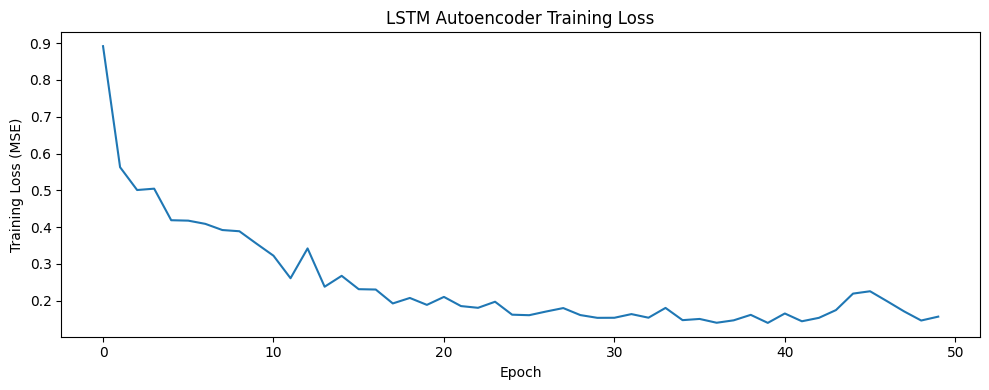

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.title("LSTM Autoencoder Training Loss")
plt.tight_layout()
plt.show()

In [14]:
model.eval()

reconstruction_errors = []

with torch.no_grad():
    for batch in test_loader:
        reconstruction = model(batch)
        error = torch.mean((reconstruction - batch) ** 2, dim=(1, 2))
        reconstruction_errors.extend(error.numpy())

reconstruction_errors = np.array(reconstruction_errors)
print(f"Number of sequence errors: {len(reconstruction_errors)}")
print(f"Min: {reconstruction_errors.min():.4f} | Max: {reconstruction_errors.max():.4f} | Mean: {reconstruction_errors.mean():.4f}")

Number of sequence errors: 4005
Min: 0.0139 | Max: 12.8693 | Mean: 0.1725


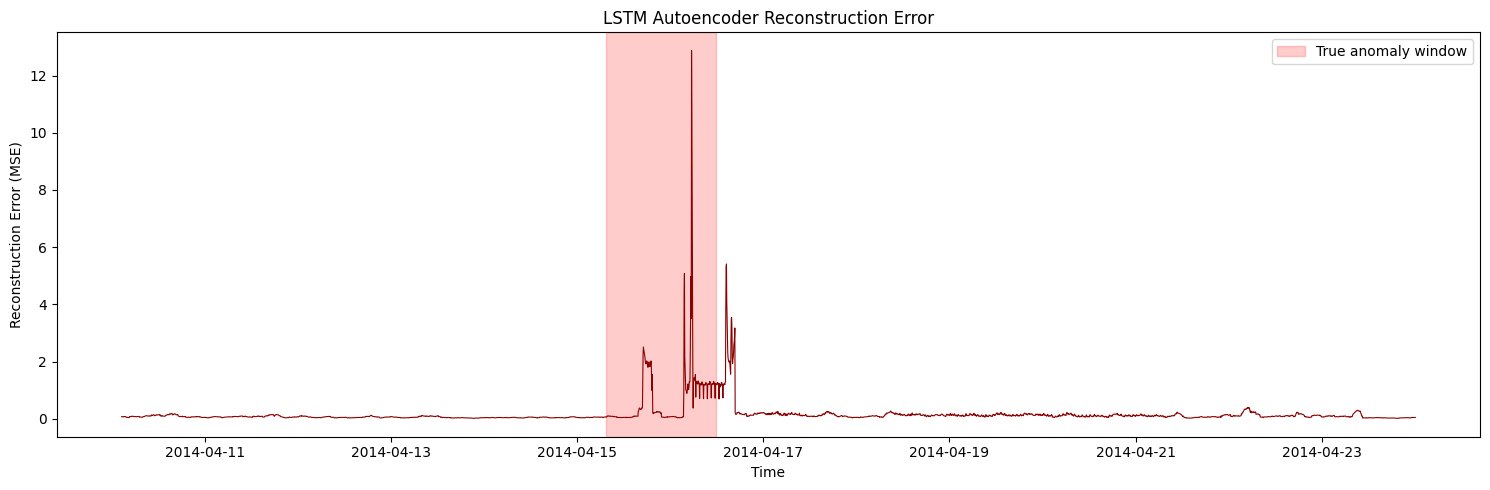

In [15]:
error_timestamps = test_df.index[SEQ_LENGTH - 1:]

error_df = pd.DataFrame({
    "timestamp": error_timestamps,
    "reconstruction_error": reconstruction_errors,
}).set_index("timestamp")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(error_df.index, error_df["reconstruction_error"], linewidth=0.8, color="darkred")
for start, end in windows:
    ax.axvspan(start, end, color="red", alpha=0.2, label="True anomaly window")
ax.set_title("LSTM Autoencoder Reconstruction Error")
ax.set_xlabel("Time")
ax.set_ylabel("Reconstruction Error (MSE)")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

threshold = reconstruction_errors.mean() + 3 * reconstruction_errors.std()
print(f"Threshold: {threshold:.4f}")

error_df["predicted_anomaly"] = (error_df["reconstruction_error"] > threshold).astype(int)

error_df["is_anomaly"] = test_df.loc[error_df.index, "is_anomaly"]

y_true = error_df["is_anomaly"]
y_pred = error_df["predicted_anomaly"]

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_true, y_pred))
print("(rows = true [normal, anomaly], cols = predicted [normal, anomaly])")

Threshold: 1.6037
Precision: 0.576
Recall:    0.111
F1-score:  0.186

Confusion matrix:
[[3634   28]
 [ 305   38]]
(rows = true [normal, anomaly], cols = predicted [normal, anomaly])


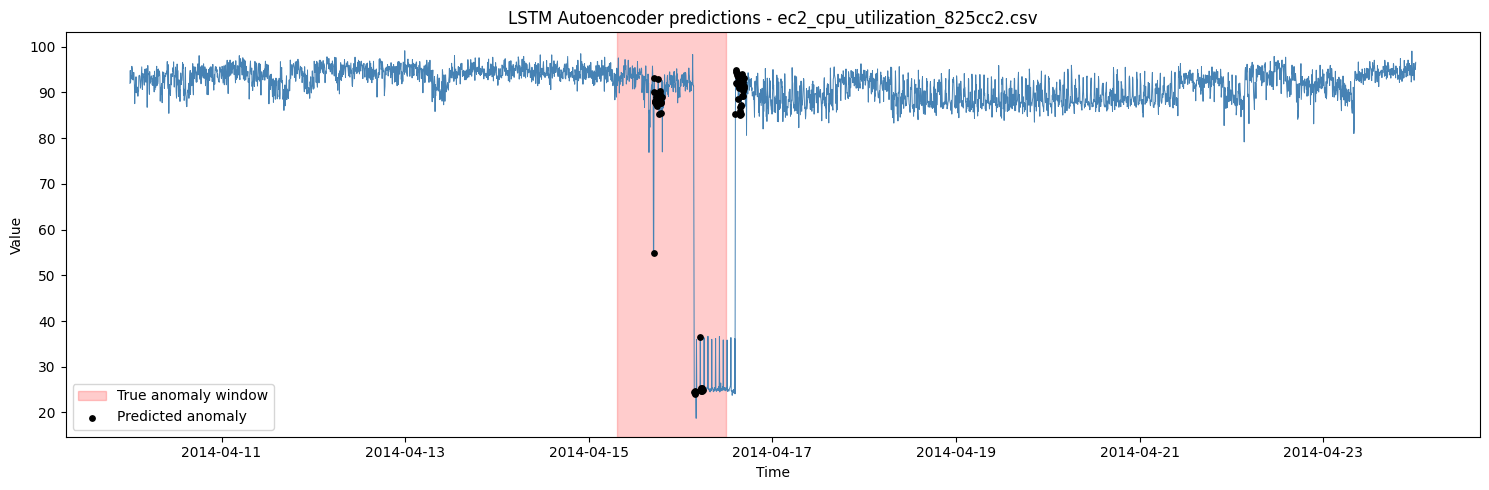

In [17]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_df.index, test_df["value"], linewidth=0.7, color="steelblue")

for start, end in windows:
    ax.axvspan(start, end, color="red", alpha=0.2, label="True anomaly window")

predicted = error_df[error_df["predicted_anomaly"] == 1]
ax.scatter(predicted.index, test_df.loc[predicted.index, "value"], color="black", s=15, zorder=5, label="Predicted anomaly")

ax.set_title(f"LSTM Autoencoder predictions - {FILENAME}")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
plt.tight_layout()
plt.show()